In [54]:
import pandas as pd
import joblib
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# df_old = pd.read_csv('../../../../data/preprocessed/selected_features_dataset_V3.csv')

In [ ]:
# df_old.columns.to_list()

['address_line_2',
 'h_id',
 'n_seven_eleven_5km',
 'n_gas_station_5km',
 'n_cafe_5km',
 'n_gas_station_in_3km_to_5km',
 'near_Olympic_Stadium_in_km',
 'n_secondary_school_5km',
 'near_Phsar_Tmey_in_km',
 'n_cafe_in_3km_to_5km',
 'near_Phsar_Chas_in_km',
 'near_Vattanac_Tower_in_km',
 'n_pre_school_5km',
 'near_Wat_Phnom_in_km',
 'n_primary_school_in_3km_to_5km',
 'price_per_m2']

In [57]:
df = pd.read_csv('../../../../data/processed/100k.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

In [58]:
LABEL_ENCODERS_PATH = "../../../../data/processed/label_encoders_v3.pkl"
SELECTED_FEATURES = ['address_line_2',
 'h_id',
 'n_cafe_5km',
 'near_Royal_Palace_in_km',
 'n_gas_station_5km',
 'near_Phsar_Tmey_in_km',
 'near_Vattanac_Tower_in_km',
 'near_Phsar_kandal_in_km',
 'near_Phsar_Chas_in_km',
 'near_Wat_Phnom_in_km',
 'near_Sisowath_Riverside_Park_in_km',
 'near_Bassac_Lane_in_km',
 'near_Olympic_Stadium_in_km',
 'near_Boeng_Keng_Kang_1_in_km',
 'n_secondary_school_5km']

In [59]:
label_encoders = joblib.load(LABEL_ENCODERS_PATH)


In [60]:
print(label_encoders)

{'address_subdivision': LabelEncoder(), 'address_locality': LabelEncoder(), 'address_line_2': LabelEncoder(), 'h_id': LabelEncoder()}


In [61]:
features = X.copy()

In [ ]:
encoded_values = {}
for col, encoder in label_encoders.items():
    if col in features:
        def encode_value(val):
            if val in encoder.classes_:
                return encoder.transform([val])[0]
            else:
                return -1  # Handle unseen label
        
        # Apply encoding row-wise
        features[col] = features[col].apply(encode_value)
        encoded_values[col] = features[col]


In [63]:
X.head()

,address_subdivision,address_locality,address_line_2,h_id,land_area,price,longitude,latitude,near_Koh_Pich_in_km,Koh_Pich_nearest,...,f_road,f_secondary,f_service,f_steps,f_tertiary,f_track,f_trunk,f_trunk_link,f_unclassified,f_unused
0,Phnom Penh,Praek Pnov,Samraong,886580d009fffff,132,132,104.830384,11.717244,22,0,...,0,0,0,0,0,0,0,0,0,0
1,Phnom Penh,Pur SenChey,Kamboul,8865846ea7fffff,174,174,104.741205,11.547118,21,0,...,0,0,0,0,1,1,0,0,1,0
2,Phnom Penh,Chraoy Chongvar,Preaek Ta Sek,886580d26dfffff,150,150,104.881978,11.676204,15,0,...,0,0,1,0,0,0,0,0,0,0
3,Phnom Penh,Pur SenChey,Ovlaok,8865846c3bfffff,152,152,104.759005,11.579001,20,0,...,0,0,0,0,0,0,0,0,0,0
4,Phnom Penh,Pur SenChey,Boeng Thum,8865846521fffff,96,96,104.770540,11.482552,20,0,...,0,0,1,0,0,0,0,0,0,0


In [64]:
features.head()

,address_subdivision,address_locality,address_line_2,h_id,land_area,price,longitude,latitude,near_Koh_Pich_in_km,Koh_Pich_nearest,...,f_road,f_secondary,f_service,f_steps,f_tertiary,f_track,f_trunk,f_trunk_link,f_unclassified,f_unused
0,0,6,73,0,132,132,104.830384,11.717244,22,0,...,0,0,0,0,0,0,0,0,0,0
1,0,8,25,684,174,174,104.741205,11.547118,21,0,...,0,0,0,0,1,1,0,0,1,0
2,0,2,66,49,150,150,104.881978,11.676204,15,0,...,0,0,1,0,0,0,0,0,0,0
3,0,8,43,518,152,152,104.759005,11.579001,20,0,...,0,0,0,0,0,0,0,0,0,0
4,0,8,9,270,96,96,104.770540,11.482552,20,0,...,0,0,1,0,0,0,0,0,0,0


In [65]:
features = features[SELECTED_FEATURES]

In [66]:
def predict_with_models(X_processed, models):
    predictions = {}
    for name, model in models.items():
        predictions[name] = model.predict(X_processed)
    return pd.DataFrame(predictions)

In [67]:
lr_model = joblib.load("../../../../models/linear_regression/linear_regression_model_v4.joblib")
rf_model = joblib.load("../../../../models/random_forest/random_forest_model_v7_label.joblib")
xgb_model = joblib.load("../../../../models/xgboost/xgboost_model_label_v7.joblib")
svr_model = joblib.load("../../../../models/svr/svr_model_label_v5.joblib")
knn_model = joblib.load("../../../../models/knn/knn_model_v2.joblib")
br_model = joblib.load("../../../../models/bayesian_ridge/bayesian_ridge_model_label_v2.joblib")

In [ ]:
models = {
    "LR": lr_model,
    # "RF": rf_model,
    "XGBoost": xgb_model,
    "SVR": svr_model,
    "KNN": knn_model,
    "BR": br_model
}

In [69]:
from collections import OrderedDict


In [70]:
from collections import OrderedDict
import math

for name, model in models.items():
    params = model.get_params()
    # Keep items where value is neither None nor 0
    filtered_params = OrderedDict(
        (k, v) for k, v in params.items() if v is not None and v != 0
    )
    
    print(f"--- {name} Parameters ---")
    print(dict(filtered_params))  # print as normal dict
    print()


--- LR Parameters ---
{'cv': 5, 'error_score': nan, 'estimator__copy_X': True, 'estimator__fit_intercept': True, 'estimator': LinearRegression(), 'n_iter': 10, 'param_distributions': {'copy_X': [True, False], 'fit_intercept': [True, False], 'n_jobs': [None, 1, -1], 'positive': [True, False]}, 'pre_dispatch': '2*n_jobs', 'refit': True}

--- XGBoost Parameters ---
{'objective': 'reg:squarederror', 'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'missing': nan, 'n_estimators': 200, 'n_jobs': -1, 'random_state': 42, 'reg_lambda': 0.5, 'subsample': 0.7}

--- SVR Parameters ---
{'steps': [('standardscaler', StandardScaler()), ('svr', SVR(C=100, degree=2))], 'standardscaler': StandardScaler(), 'svr': SVR(C=100, degree=2), 'standardscaler__copy': True, 'standardscaler__with_mean': True, 'standardscaler__with_std': True, 'svr__C': 100, 'svr__cache_size': 200, 'svr__degree': 2, 'svr__epsilon': 0.1, 'svr__gamma': 'scale', 'svr__kernel': 'rbf', 'svr__max_iter': -1, 'svr__shrinking'

In [71]:
# def get_used_feature_names(models_dict):
#     """Get the feature names used by each model"""
#     feature_info = {}
    
#     for name, model in models_dict.items():
#         try:
#             # Scikit-learn models (v1.0+)
#             if hasattr(model, 'feature_names_in_'):
#                 feature_info[name] = list(model.feature_names_in_)
            
#             # XGBoost models
#             elif hasattr(model, 'get_booster'):
#                 feature_info[name] = model.get_booster().feature_names
            
#             # Models with coefficients (Linear, BayesianRidge)
#             elif hasattr(model, 'coef_'):
#                 if hasattr(model, 'feature_names_in_'):
#                     feature_info[name] = list(model.feature_names_in_)
#                 else:
#                     feature_info[name] = [f"feature_{i}" for i in range(len(model.coef_))]
            
#             # Models with feature_importances_
#             elif hasattr(model, 'feature_importances_'):
#                 if hasattr(model, 'feature_names_in_'):
#                     feature_info[name] = list(model.feature_names_in_)
#                 else:
#                     feature_info[name] = [f"feature_{i}" for i in range(len(model.feature_importances_))]
            
#             else:
#                 feature_info[name] = "Feature names not available"
                
#         except Exception as e:
#             feature_info[name] = f"Error: {str(e)}"
    
#     return pd.DataFrame.from_dict(feature_info, orient='index').T

# # Usage after model training:
# feature_names_df = get_used_feature_names(models)
# print("Features used by each model:")
# display(feature_names_df)

In [72]:
preds_df = predict_with_models(features, models)

In [73]:
preds_df

,LR,XGBoost,SVR,KNN,BR
0,-323.189138,498.594269,257.981805,219.6402,252.974574
1,348.562606,877.548340,303.848634,733.0886,494.666499
2,340.695053,739.192505,498.582512,690.4856,502.308593
3,169.842122,567.846863,241.639492,109.6870,561.982457
4,604.750940,641.783997,276.659644,161.7056,546.017716
...,...,...,...,...,...
99995,300.407137,584.400513,216.496220,160.7324,351.804716
99996,1161.666780,1465.093018,1179.330021,1215.4200,926.176774
99997,243.174414,900.691650,689.926246,679.1170,993.094007
99998,1478.511326,1286.190186,1242.862157,1148.3760,1146.702264


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

def evaluate_models(y_true, predictions_df):
    results = []

    for model_name in predictions_df.columns:
        y_pred = predictions_df[model_name]
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)

        results.append({
            'Model': model_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
            'MAPE (%)': mape
        })

    return pd.DataFrame(results).sort_values(by='RMSE')


In [75]:
evaluation_results = evaluate_models(y, preds_df)

In [76]:
print(evaluation_results)

     Model         MAE            MSE        RMSE        R2    MAPE (%)
3      KNN  239.895265  175168.378832  418.531216  0.880031   40.776335
1  XGBoost  361.490418  202586.944206  450.096594  0.861252  110.841496
2      SVR  302.760791  253206.442892  503.196227  0.826584   45.722869
4       BR  340.736020  262892.024436  512.729972  0.819951   66.037125
0       LR  506.503665  548368.655874  740.519180  0.624433   89.071962


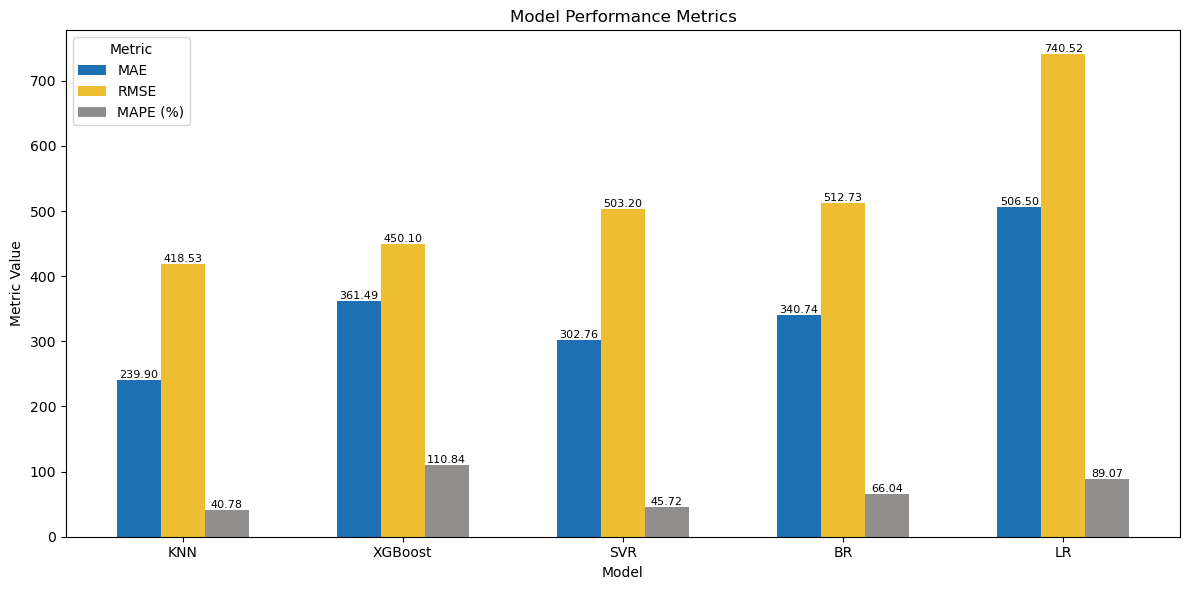

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

# Your evaluation results DataFrame
# Make sure `evaluation_results` is already defined and contains columns: Model, MAE, MSE, RMSE, R2, MAPE (%)
metrics_to_plot = ['MAE', 'RMSE', 'MAPE (%)']

# Convert wide to long format for plotting
df_long = evaluation_results.melt(id_vars='Model', value_vars=metrics_to_plot,
                                  var_name='Metric', value_name='Value')

# Sort models for consistent display
models = df_long['Model'].unique()
metrics = df_long['Metric'].unique()

# Define bar width and positions
bar_width = 0.2
x = range(len(models))

# Plotting
plt.figure(figsize=(12, 6))
custom_colors = {
    'MAE': "#1D70B3",       # Blue
    'RMSE': "#EDBE31",      # Green
    'MAPE (%)': "#918E8E"   # Purple
}

for i, metric in enumerate(metrics):
    data = df_long[df_long['Metric'] == metric]
    x_positions = [pos + i * bar_width for pos in x]
    bars = plt.bar(x_positions, data['Value'], width=bar_width, label=metric, color=custom_colors[metric])

    # Add number labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# Configure x-axis
plt.xticks([pos + bar_width * (len(metrics) - 1) / 2 for pos in x], models)
plt.xlabel('Model')
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [78]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

def evaluate_by_location(X_raw, y_true, predictions_df, location_col='address_locality'):
    results = []

    for model_name in predictions_df.columns:
        df = X_raw.copy()
        df['y_true'] = y_true
        df['y_pred'] = predictions_df[model_name]
        df['abs_error'] = np.abs(df['y_true'] - df['y_pred'])
        df['squared_error'] = (df['y_true'] - df['y_pred']) ** 2
        df['abs_pct_error'] = np.abs((df['y_true'] - df['y_pred']) / np.clip(df['y_true'], 1e-8, None)) * 100

        grouped = df.groupby(location_col).agg(
            count=('y_true', 'size'),
            MAE=('abs_error', 'mean'),
            MSE=('squared_error', 'mean'),
            RMSE=('squared_error', lambda x: np.sqrt(np.mean(x))),
            MAPE=('abs_pct_error', 'mean')
        ).reset_index()

        # Calculate R2 for each group, safely skipping groups with NaNs or no variation in y_true
        r2_values = []
        for loc in grouped[location_col]:
            group = df[df[location_col] == loc][['y_true', 'y_pred']].dropna()
            if not group.empty and group['y_true'].nunique() > 1:
                r2 = r2_score(group['y_true'], group['y_pred'])
            else:
                r2 = np.nan
            r2_values.append(r2)

        grouped['R2'] = r2_values
        grouped['Model'] = model_name
        results.append(grouped)

    return pd.concat(results, ignore_index=True)

In [79]:
grouped_by_location_df = evaluate_by_location(X, y, preds_df)

knn_results = grouped_by_location_df[grouped_by_location_df['Model'] == 'KNN']

In [80]:
knn_results

,address_locality,count,MAE,MSE,RMSE,MAPE,R2,Model
36,Chamkar Mon,1980,604.744194,6.871427e+05,828.940708,13.216763,0.542339,KNN
37,Chbar Ampov,13184,237.293101,1.971426e+05,444.007426,35.199534,0.192511,KNN
38,Chraoy Chongvar,11847,320.270459,2.615710e+05,511.440163,69.586196,0.512372,KNN
39,Dangkao,18414,194.343084,8.680073e+04,294.619638,48.461411,0.442868,KNN
40,Doun Penh,1451,943.925080,1.611543e+06,1269.465695,18.088002,0.520192,KNN
41,Mean Chey,4173,463.089132,4.740559e+05,688.517198,19.991530,-0.660098,KNN
42,Praek Pnov,13910,114.631130,2.841063e+04,168.554531,43.451015,0.644121,KNN
43,Prampir Meakkakra,377,841.851806,1.145671e+06,1070.360255,19.244861,-0.257763,KNN
44,Pur SenChey,21808,136.645666,4.323675e+04,207.934489,41.693119,0.894127,KNN
45,Russey Keo,4055,340.512292,2.946994e+05,542.862199,23.009277,0.070257,KNN


In [81]:
from sklearn.model_selection import train_test_split

In [82]:
X_old = df_old.drop(['price_per_m2'], axis=1)
y_old = df_old['price_per_m2']
X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(X_old, y_old, test_size=0.2, random_state=42)

In [83]:
X_test_old

,address_line_2,h_id,n_seven_eleven_5km,n_gas_station_5km,n_cafe_5km,n_gas_station_in_3km_to_5km,near_Olympic_Stadium_in_km,n_secondary_school_5km,near_Phsar_Tmey_in_km,n_cafe_in_3km_to_5km,near_Phsar_Chas_in_km,near_Vattanac_Tower_in_km,n_pre_school_5km,near_Wat_Phnom_in_km,n_primary_school_in_3km_to_5km
1801,25,463,1.0,1.0,-0.0,1,17.038438,0.0,17.851071,1,18.829067,18.057132,1.0,19.120830,0
1190,87,402,36.0,170.0,181.0,74,0.000000,81.0,1.805540,67,2.831681,2.202065,97.0,2.922115,31
1817,30,325,12.0,77.0,67.0,56,6.032393,33.0,4.790659,47,5.026913,3.975565,38.0,3.992670,14
251,77,416,37.0,154.0,191.0,73,1.322679,81.0,0.276916,82,0.929937,0.177068,100.0,1.067435,34
2505,43,501,0.0,0.0,2.0,0,20.018623,0.0,20.882259,0,21.944407,20.886849,0.0,21.139923,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,12,150,10.0,50.0,52.0,41,5.951927,19.0,6.813827,39,7.104776,7.122951,21.0,8.049276,16
2087,67,725,1.0,10.0,8.0,10,11.901100,5.0,12.069603,6,12.135725,12.991539,1.0,12.888659,0
599,13,163,16.0,58.0,69.0,43,6.075258,30.0,6.973189,58,6.953710,6.965542,34.0,6.796246,17
1756,62,73,3.0,6.0,3.0,4,12.916556,-0.0,13.853297,1,15.213420,15.094291,1.0,14.874731,0


In [86]:
models = {
    "LR": lr_model,
    # "RF": rf_model,
    "XGBoost": xgb_model,
    "SVR": svr_model,
    "KNN": knn_model,
    "BR": br_model
}

In [ ]:
# preds_df_old = predict_with_models(X_test_old, models)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- n_cafe_in_3km_to_5km
- n_gas_station_in_3km_to_5km
- n_pre_school_5km
- n_primary_school_in_3km_to_5km
- n_seven_eleven_5km
Feature names seen at fit time, yet now missing:
- near_Bassac_Lane_in_km
- near_Boeng_Keng_Kang_1_in_km
- near_Phsar_kandal_in_km
- near_Royal_Palace_in_km
- near_Sisowath_Riverside_Park_in_km


In [88]:
evaluation_results_old = evaluate_models(y_test_old, preds_df_old)

NameError: name 'preds_df_old' is not defined

In [ ]:
evaluation_results_old

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Select metrics
metrics_to_plot = ['MAE', 'RMSE', 'MAPE (%)']

# Sort evaluation_results_old by MAE
sorted_df = evaluation_results_old.sort_values(by='MAE', ascending=True)
sorted_models = sorted_df['Model'].tolist()

# Melt for long format plotting
df_long = sorted_df.melt(id_vars='Model', value_vars=metrics_to_plot,
                         var_name='Metric', value_name='Value')

# Ensure model order is preserved
df_long['Model'] = pd.Categorical(df_long['Model'], categories=sorted_models, ordered=True)

# Bar setup
bar_width = 0.2
models = df_long['Model'].cat.categories.tolist()
metrics = df_long['Metric'].unique()
x = list(range(len(models)))

# Colors
custom_colors = {
    'MAE': "#1D70B3",       # Blue
    'RMSE': "#EDBE31",      # Yellow-Gold
    'MAPE (%)': "#918E8E"   # Gray
}

# Plot
plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics):
    data = df_long[df_long['Metric'] == metric]
    x_positions = [pos + i * bar_width for pos in x]
    bars = plt.bar(x_positions, data['Value'], width=bar_width,
                   label=metric, color=custom_colors[metric])

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# X-axis and labels
plt.xticks([pos + bar_width * (len(metrics) - 1) / 2 for pos in x], models)
plt.xlabel('Model')
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics Bar')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [ ]:
y_test_old.isnull().sum()

In [ ]:
grouped_by_location_df_old = evaluate_by_location(X_test_old, y_test_old, preds_df_old, location_col="address_line_2")

knn_results = grouped_by_location_df_old[grouped_by_location_df_old['Model'] == 'RF']

In [ ]:
knn_results

In [ ]:
encoder = label_encoders['address_line_2']
knn_results['address_line_2'] = encoder.inverse_transform(knn_results['address_line_2'].astype(int))

In [ ]:
total_count = knn_results['count'].sum()
print("Total count:", total_count)


In [ ]:
knn_results

In [ ]:
knn_evaluation_results_old = evaluation_results_old[evaluation_results_old['Model'] == 'KNN']
knn_evaluation_results_old

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

def evaluate_by_price_range(X_raw, y_true, predictions_df, price_col='y_true'):
    results = []

    # Define price bins (you can adjust bins for better accuracy)
    price_bins = [40, 100, 200, 500, 1000, 2000, 4000, 6000, 8000, 10000, 12000]
    price_labels = ['40-100', '100-200', '200-500', '500-1k', '1k-2k', '2k-4k', '4k-6k', '6k-8k', '8k-10k', '10k-12k']

    for model_name in predictions_df.columns:
        df = X_raw.copy()
        df['y_true'] = y_true
        df['y_pred'] = predictions_df[model_name]
        df['abs_error'] = np.abs(df['y_true'] - df['y_pred'])
        df['squared_error'] = (df['y_true'] - df['y_pred']) ** 2
        df['abs_pct_error'] = np.abs((df['y_true'] - df['y_pred']) / np.clip(df['y_true'], 1e-8, None)) * 100

        # Assign price ranges to y_true
        df['price_range'] = pd.cut(df['y_true'], bins=price_bins, labels=price_labels, include_lowest=True)

        grouped = df.groupby('price_range').agg(
            count=('y_true', 'size'),
            MAE=('abs_error', 'mean'),
            MSE=('squared_error', 'mean'),
            RMSE=('squared_error', lambda x: np.sqrt(np.mean(x))),
            MAPE=('abs_pct_error', 'mean')
        ).reset_index()

        # Calculate R2 for each price range, handling NaNs and constant values
        r2_values = []
        for pr in grouped['price_range']:
            group = df[df['price_range'] == pr][['y_true', 'y_pred']].dropna()
            if not group.empty and group['y_true'].nunique() > 1:
                r2 = r2_score(group['y_true'], group['y_pred'])
            else:
                r2 = np.nan
            r2_values.append(r2)

        grouped['R2'] = r2_values
        grouped['Model'] = model_name
        results.append(grouped)

    return pd.concat(results, ignore_index=True)


In [ ]:
grouped_by_price_df = evaluate_by_price_range(X_test_old, y_test_old, preds_df)
knn_price_results = grouped_by_price_df[grouped_by_price_df['Model'] == 'RF']

In [ ]:
knn_price_results

In [ ]:
def evaluate_by_price_quantiles(X_raw, y_true, predictions_df, n_bins=10):
    results = []
    quantile_bins = pd.qcut(y_true, q=n_bins, duplicates='drop')
    
    for model_name in predictions_df.columns:
        df = X_raw.copy()
        df['y_true'] = y_true
        df['y_pred'] = predictions_df[model_name]
        df['abs_error'] = np.abs(df['y_true'] - df['y_pred'])
        df['squared_error'] = (df['y_true'] - df['y_pred']) ** 2
        df['abs_pct_error'] = np.abs((df['y_true'] - df['y_pred']) / np.clip(df['y_true'], 1e-8, None)) * 100
        
        df['price_range'] = quantile_bins

        grouped = df.groupby('price_range').agg(
            count=('y_true', 'size'),
            MAE=('abs_error', 'mean'),
            MSE=('squared_error', 'mean'),
            RMSE=('squared_error', lambda x: np.sqrt(np.mean(x))),
            MAPE=('abs_pct_error', 'mean')
        ).reset_index()

        r2_values = []
        for pr in grouped['price_range']:
            group = df[df['price_range'] == pr][['y_true', 'y_pred']].dropna()
            if not group.empty and group['y_true'].nunique() > 1:
                r2 = r2_score(group['y_true'], group['y_pred'])
            else:
                r2 = np.nan
            r2_values.append(r2)

        grouped['R2'] = r2_values
        grouped['Model'] = model_name
        results.append(grouped)

    return pd.concat(results, ignore_index=True)


In [ ]:
grouped_by_bin_df = evaluate_by_price_quantiles(X_test_old, y_test_old, preds_df)
knn_bin_results = grouped_by_bin_df[grouped_by_bin_df['Model'] == 'KNN']
knn_bin_results

In [ ]:
grouped_by_bin_df = evaluate_by_price_quantiles(X, y, preds_df)
knn_results_by_bin = grouped_by_bin_df[grouped_by_bin_df['Model'] == 'KNN']
knn_results_by_bin

# GROUP DATA

In [ ]:
grouped_by_price_df = evaluate_by_price_range(X, y, preds_df)
knn_results_by_price = grouped_by_price_df[grouped_by_price_df['Model'] == 'RF']
knn_results_by_price.loc[:, knn_results_by_price.columns != 'count']

In [ ]:
grouped_by_price_df = evaluate_by_location(X, y, preds_df, location_col="address_line_2")
knn_results_by_price = grouped_by_price_df[grouped_by_price_df['Model'] == 'KNN']
pd.options.display.float_format = '{:.2f}'.format
knn_results_by_price.loc[:, knn_results_by_price.columns != 'count']

In [ ]:
print(knn_results_by_price.loc[:, knn_results_by_price.columns != 'count'])


In [ ]:
df = knn_results_by_price.loc[:, knn_results_by_price.columns != 'count'].copy()

# Round all numeric columns to 2 decimals
num_cols = df.select_dtypes(include=['float', 'int']).columns
df[num_cols] = df[num_cols].round(2)

# Sort by MAE ascending
df_sorted = df.sort_values(by='MAE', ascending=True)

print(df_sorted)

In [ ]:
grouped_by_price_df = evaluate_by_price_quantiles(X, y, preds_df)
knn_results_by_price = grouped_by_price_df[grouped_by_price_df['Model'] == 'KNN']
knn_results_by_price.loc[:, knn_results_by_price.columns != 'count']

In [ ]:
df = knn_results_by_price.loc[:, knn_results_by_price.columns != 'count'].copy()

# Round all numeric columns to 2 decimals
num_cols = df.select_dtypes(include=['float', 'int']).columns
df[num_cols] = df[num_cols].round(2)

# Sort by MAE ascending
df_sorted = df.sort_values(by='MAE', ascending=True)

print(df_sorted)

In [ ]:
def format_interval_as_int(interval):
    left = int(interval.left)
    right = int(interval.right)
    return f"({left}, {right}]"

df_sorted['price_range'] = df_sorted['price_range'].apply(format_interval_as_int)

print(df_sorted)
